# Hospital Readmission Risk Prediction
## 02. Data Sampling + Feature Engineering

This notebook mirrors **Notebook 1** and adds:
1) **Patient-level split** (per proposal 4.1) to avoid leakage — same patient never in both train and val.
2) **Feature engineering** per proposal: drop weight, handle missing values, add engineered features.
3) **class_weight='balanced'** for LR; **XGBoost / LightGBM** for comparison (proposal 4.3).
4) **OHE deep dive** — inspect feature names, sample row, top categorical values.

## Imports
- **pandas / numpy** for data wrangling
- **scikit-learn** `DictVectorizer`, `LogisticRegression`, PR-AUC
- **XGBoost / LightGBM** for model comparison (proposal 4.3)
- **seaborn / matplotlib** for visualization

In [26]:
%pip install xgboost lightgbm

  Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl (2.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [lightgbm]1/2 [lightgbm]
Note: you may need to restart the kernel to use updated packages.


In [27]:
import warnings
import time

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## Data Source & Config
Diabetes 130-US Hospitals (UCI). Target: readmitted within 30 days.

In [ ]:
DATA_PATH = '../data/diabetic_data.csv'
TARGET = 'target'
SAMPLE_FRAC = 0.20  # 20% for faster iteration; set to 1.0 to use full data
SEED = 42

## Define Data Loading + Feature Engineering

Per proposal:
- **Target**: Binary — 1 if readmitted within 30 days (`readmitted` in `['30','<30']`)
- **Drop**: `weight` (96.9% missing)
- **Missing**: `medical_specialty`, `payer_code` → "Unknown"; HbA1c "None" → "not tested"
- **Engineered**: `care_intensity` (prior visits sum), `medication_changed` (binary from `change`)
- **Sampling**: Random sample when `limit` is set (ensures both classes)

In [29]:
def read_data(path: str, limit: int = None):
    df = pd.read_csv(path)
    # Target
    df['target'] = df['readmitted'].isin(['30', '<30']).astype(int)
    # Drop weight (96.9% missing)
    if 'weight' in df.columns:
        df = df.drop(columns=['weight'])
    # Missing → Unknown / not tested (per proposal)
    for col in ['medical_specialty', 'payer_code']:
        if col in df.columns:
            df[col] = df[col].fillna('Unknown').replace('?', 'Unknown')
    for col in ['A1Cresult', 'max_glu_serum']:
        if col not in df.columns:
            df[col] = 'not_tested'
        else:
            df[col] = df[col].fillna('None').replace('None', 'not_tested')
    # Demographics
    df['age'] = df['age'].fillna('[50-60)')
    df['gender'] = df['gender'].fillna('Unknown')
    if 'race' in df.columns:
        df['race'] = df['race'].fillna('Unknown').replace('?', 'Unknown')
    df['change'] = df['change'].fillna('No')
    df['diabetesMed'] = df['diabetesMed'].fillna('No')
    # Engineered: care intensity (prior year visits)
    for col in ['number_emergency', 'number_inpatient', 'number_outpatient']:
        if col not in df.columns:
            df[col] = 0
        else:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
    df['care_intensity'] = df['number_emergency'] + df['number_inpatient'] + df['number_outpatient']
    # Engineered: medication changed flag (Ch = changed)
    df['medication_changed'] = (df['change'] == 'Ch').astype(int)
    # Numeric cols
    for col in ['num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses']:
        if col not in df.columns:
            df[col] = 0
        else:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
    if limit is not None:
        df = df.sample(n=min(limit, len(df)), random_state=SEED)
    return df

## Load Data & Patient-Level Split (per proposal 4.1)
Split by **patient_nbr** so the same patient never appears in both train and val. Prevents leakage across 16,773 patients with multiple encounters.

In [30]:
df = read_data(DATA_PATH, limit=80_000)

# Patient-level split: each patient's target = 1 if any encounter readmitted
patient_target = df.groupby('patient_nbr')[TARGET].max()
train_patients, val_patients = train_test_split(
    patient_target.index.tolist(), test_size=0.2, random_state=SEED, stratify=patient_target.values
)
df_train = df[df['patient_nbr'].isin(train_patients)].copy()
df_val = df[df['patient_nbr'].isin(val_patients)].copy()

print(f'Train rows: {len(df_train):,};  Val rows: {len(df_val):,}')
print(f'Train patients: {len(train_patients):,};  Val patients: {len(val_patients):,}')
print(f'Target positive rate (train): {df_train[TARGET].mean():.2%}')
df_train.head(3)

Train rows: 63,879;  Val rows: 16,121
Train patients: 47,413;  Val patients: 11,854
Target positive rate (train): 11.19%


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,target,care_intensity,medication_changed
35956,110939484,19274094,Caucasian,Female,[70-80),1,1,6,11,UN,...,No,No,No,No,No,Yes,NO,0,0,0
79920,245688426,100657359,Caucasian,Female,[60-70),3,6,1,4,HM,...,No,No,No,No,No,Yes,NO,0,3,0
44080,135993852,65234214,AfricanAmerican,Female,[60-70),1,2,7,1,Unknown,...,No,No,No,No,No,Yes,<30,1,0,0


## Optional Deterministic Sampling
Further subsample train/val for faster iteration. Set `SAMPLE_FRAC=1.0` to disable.

In [31]:
len_train_before, len_val_before = len(df_train), len(df_val)

if SAMPLE_FRAC < 1.0:
    df_train = df_train.sample(frac=SAMPLE_FRAC, random_state=SEED)
    df_val = df_val.sample(frac=SAMPLE_FRAC, random_state=SEED)

print(f'Train size: {len_train_before:,} -> {len(df_train):,}')
print(f'Val   size: {len_val_before:,} -> {len(df_val):,}')

Train size: 63,879 -> 12,776
Val   size: 16,121 -> 3,224


## Feature Columns (with Engineered Features)
Include demographics, admission context, clinical utilization, lab results, and engineered `care_intensity`, `medication_changed`.

In [32]:
FEATURE_COLS = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
    'number_emergency', 'number_inpatient', 'number_outpatient', 'number_diagnoses',
    'care_intensity',  # engineered
    'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
    'age', 'gender', 'race',
    'change', 'diabetesMed', 'medication_changed',  # medication flags (medication_changed is 0/1)
    'A1Cresult', 'max_glu_serum',  # lab results
]
# Keep only columns that exist
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_train.columns]

# Ensure categoricals are strings
for col in ['age', 'gender', 'race', 'change', 'diabetesMed', 'A1Cresult', 'max_glu_serum']:
    if col in df_train.columns:
        df_train[col] = df_train[col].astype(str)
        df_val[col] = df_val[col].astype(str)

## Prepare Features (One-Hot Encoding)
Use `DictVectorizer` to one-hot encode. No SMOTE — we use **class_weight='balanced'** and tree models for imbalance.

In [33]:
train_dicts = df_train[FEATURE_COLS].to_dict(orient='records')
val_dicts = df_val[FEATURE_COLS].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)

y_train = df_train[TARGET].values
y_val = df_val[TARGET].values

print('Feature matrix (train):', X_train.shape)
print('Number of OHE features:', len(dv.feature_names_))
print(f'Target positive rate (train): {y_train.mean():.2%}')

Feature matrix (train): (12776, 44)
Number of OHE features: 44
Target positive rate (train): 11.50%


### OHE Quick Peek
- How many features? Non-zero features for first row?
- Top-10 most frequent `age` groups

In [34]:
feature_names = dv.get_feature_names_out()
print('Num OHE features:', len(feature_names))

row = 0
nz_cols = X_train[row].nonzero()[1]
decoded = [(feature_names[i], X_train[row, i]) for i in nz_cols]
pd.DataFrame(decoded, columns=['feature', 'value']).head(15)

Num OHE features: 44


,feature,value
0,A1Cresult=not_tested,1.0
1,admission_source_id,7.0
2,admission_type_id,1.0
3,age=[40-50),1.0
4,change=Ch,1.0
5,diabetesMed=Yes,1.0
6,discharge_disposition_id,1.0
7,gender=Male,1.0
8,max_glu_serum=not_tested,1.0
9,medication_changed,1.0


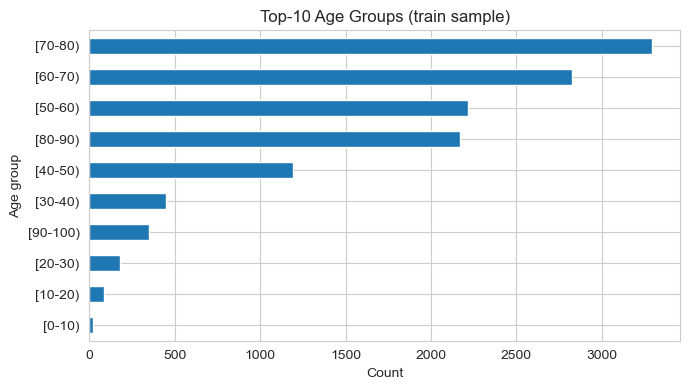

In [35]:
top_age = df_train['age'].value_counts().head(10).sort_values(ascending=True)
plt.figure(figsize=(7, 4))
top_age.plot(kind='barh')
plt.xlabel('Count')
plt.ylabel('Age group')
plt.title('Top-10 Age Groups (train sample)')
plt.tight_layout()
plt.show()

## Train Models: LR (baseline) + XGBoost + LightGBM
Per proposal 4.3: LR with **class_weight='balanced'**; XGBoost/LightGBM handle imbalance natively.

In [36]:
# Convert to dense for XGBoost/LightGBM (they need arrays)
X_train_dense = X_train.toarray() if hasattr(X_train, 'toarray') else X_train
X_val_dense = X_val.toarray() if hasattr(X_val, 'toarray') else X_val

# 1. Logistic Regression with class_weight='balanced'
lr = LogisticRegression(max_iter=500, random_state=SEED, class_weight='balanced')
lr.fit(X_train, y_train)
y_proba_lr = lr.predict_proba(X_val)[:, 1]

# 2. XGBoost (scale_pos_weight for imbalance)
scale_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
xgb_model = xgb.XGBClassifier(objective='binary:logistic', max_depth=6, n_estimators=100,
                               scale_pos_weight=scale_pos, random_state=SEED, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_dense, y_train)
y_proba_xgb = xgb_model.predict_proba(X_val_dense)[:, 1]

# 3. LightGBM (scale_pos_weight for imbalance)
lgb_model = lgb.LGBMClassifier(max_depth=6, n_estimators=100, scale_pos_weight=scale_pos, random_state=SEED, verbose=-1)
lgb_model.fit(X_train_dense, y_train)
y_proba_lgb = lgb_model.predict_proba(X_val_dense)[:, 1]

# Compare validation PR-AUC
results = []
for name, proba in [('LogisticRegression', y_proba_lr), ('XGBoost', y_proba_xgb), ('LightGBM', y_proba_lgb)]:
    pr_auc = average_precision_score(y_val, proba)
    roc_auc = roc_auc_score(y_val, proba)
    results.append({'Model': name, 'PR-AUC': pr_auc, 'ROC-AUC': roc_auc})
    print(f'{name}: PR-AUC={pr_auc:.3f}, ROC-AUC={roc_auc:.3f}')

best = max(results, key=lambda x: x['PR-AUC'])
print(f"\nBest by PR-AUC: {best['Model']} ({best['PR-AUC']:.3f})")

LogisticRegression: PR-AUC=0.180, ROC-AUC=0.635
XGBoost: PR-AUC=0.163, ROC-AUC=0.595
LightGBM: PR-AUC=0.183, ROC-AUC=0.635

Best by PR-AUC: LightGBM (0.183)


### Quick Visual Check (LR predictions)

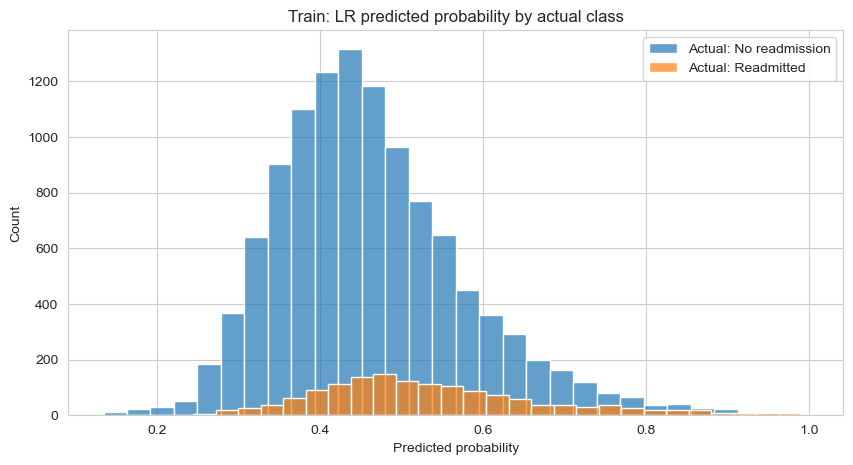

In [37]:
y_proba_train_lr = lr.predict_proba(X_train)[:, 1]
sns.histplot(y_proba_train_lr[y_train == 0], label='Actual: No readmission', stat='count', bins=30, alpha=0.7)
sns.histplot(y_proba_train_lr[y_train == 1], label='Actual: Readmitted', stat='count', bins=30, alpha=0.7)
plt.legend()
plt.xlabel('Predicted probability')
plt.ylabel('Count')
plt.title('Train: LR predicted probability by actual class')
plt.show()

## Validation Summary
Comparison table (validation set). Best model by PR-AUC is promoted per proposal 4.3.

In [38]:
pd.DataFrame(results).round(3)

,Model,PR-AUC,ROC-AUC
0,LogisticRegression,0.180,0.635
1,XGBoost,0.163,0.595
2,LightGBM,0.183,0.635
